# Tutorial 4: LSTM Ground Motion Prediction
### Fast · Robust · Full Analysis — Matching ANN Experiment Structure

In [5]:
# Run once if needed:
# import sys; import subprocess
# subprocess.run([sys.executable,"-m","pip","install",
#   "python-calamine","shap","tqdm","scikit-learn","torch",
#   "pandas","numpy","matplotlib","openpyxl"], check=True)
print("Libraries assumed installed.")

Libraries assumed installed.


## 0. Imports & Configuration

In [6]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import warnings, os, copy
warnings.filterwarnings('ignore')
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torch.amp import autocast, GradScaler

SEED = 42; torch.manual_seed(SEED); np.random.seed(SEED)
device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = device.type == "cuda"
print(f"PyTorch {torch.__version__} | Device: {device} | AMP: {USE_AMP}")
plt.rcParams.update({'figure.dpi':120,'font.size':10,'axes.grid':True,
                     'grid.alpha':0.4,'grid.linestyle':'--'})

PyTorch 2.10.0 | Device: cpu | AMP: False


## 1. Load Data

In [8]:
FILE = "NGAsub_MegaFlatfile_RotD50_050_R211022_public.xlsx"

def col2period(c): return float(c[1:-1].replace('pt','.'))

print("Reading column names ...")
tmp = pd.read_excel(FILE, engine='calamine', nrows=0)
all_cols = tmp.columns.tolist()
period_cols = sorted([c for c in all_cols if c.startswith('T') and c.endswith('S')
                       and col2period(c) <= 4.0], key=col2period)
periods_arr = np.array([col2period(c) for c in period_cols])

base = ['Earthquake_Magnitude','ClstD_km','Vs30_Selected_for_Analysis_m_s',
        'Fault_Type','PGA_g','PGV_cm_sec']
usecols = base + period_cols
dtypes  = {c:'float32' for c in usecols}; dtypes['Fault_Type']='int8'

print(f"Loading {len(usecols)} columns ...")
df = pd.read_excel(FILE, engine='calamine', usecols=usecols, dtype=dtypes)
print(f"Raw shape: {df.shape}")

Reading column names ...
Loading 96 columns ...
Raw shape: (71340, 96)


## 2. Filtering & Feature Engineering

In [9]:
# Same filters as ANN (tut3.py)
df = df[(df.Earthquake_Magnitude >= 4) &
        (df.ClstD_km > 0) &
        (df.Vs30_Selected_for_Analysis_m_s > 0) &
        (df.PGA_g > 0) & (df.PGA_g < 5) &
        (df.PGV_cm_sec > 0) & (df.PGV_cm_sec < 500) &
        (df.Fault_Type.notna())]
for c in tqdm(period_cols, desc="Filter Sa"):
    df = df[(df[c] > 0) & (df[c] < 5)]
df = df.reset_index(drop=True)
print(f"After filtering: {len(df):,} records")

df['log10_Rrp']  = np.log10(df.ClstD_km)
df['log10_Vs30'] = np.log10(df.Vs30_Selected_for_Analysis_m_s)
df['log10_PGA']  = np.log10(df.PGA_g)
df['log10_PGV']  = np.log10(df.PGV_cm_sec)
log_sa = []
for c in tqdm(period_cols, desc="Log Sa"):
    lc = f'log10_{c}'; df[lc] = np.log10(df[c]); log_sa.append(lc)

INPUT_COLS  = ['Earthquake_Magnitude','ClstD_km','log10_Rrp','log10_Vs30','Fault_Type']
TARGET_COLS = ['log10_PGA','log10_PGV'] + log_sa   # 92 outputs

valid = np.isfinite(df[INPUT_COLS + TARGET_COLS].values).all(axis=1)
df = df[valid].reset_index(drop=True)
print(f"Final: {len(df):,} records | {len(INPUT_COLS)} inputs | {len(TARGET_COLS)} targets")

Filter Sa: 100%|██████████| 90/90 [00:00<00:00, 490.28it/s]


After filtering: 65,167 records


Log Sa: 100%|██████████| 90/90 [00:00<00:00, 3690.65it/s]

Final: 65,167 records | 5 inputs | 92 targets


## 3. Train / Validation / Test Split

In [10]:
X_all = df[INPUT_COLS].values
y_all = df[TARGET_COLS].values

X_tr_full, X_test, y_tr_full, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val       = train_test_split(X_tr_full, y_tr_full, test_size=0.2, random_state=42)

sX = StandardScaler(); X_train_s = sX.fit_transform(X_train)
X_val_s  = sX.transform(X_val);  X_test_s  = sX.transform(X_test)
sy = StandardScaler(); y_train_s = sy.fit_transform(y_train)
y_val_s  = sy.transform(y_val);  y_test_s  = sy.transform(y_test)

# Subsample for HP search  (keeps each run fast)
SUB = 12_000
idx  = np.random.choice(len(X_train_s), min(SUB, len(X_train_s)), replace=False)
idx2 = np.random.choice(len(X_val_s),   min(3000, len(X_val_s)),  replace=False)
Xh_tr=X_train_s[idx]; yh_tr=y_train_s[idx]
Xh_vl=X_val_s[idx2];  yh_vl=y_val_s[idx2]

print(f"Train:{X_train.shape[0]:,}  Val:{X_val.shape[0]:,}  Test:{X_test.shape[0]:,}")
print(f"HP subsample -> train:{len(Xh_tr):,}  val:{len(Xh_vl):,}")

Train:41,706  Val:10,427  Test:13,034
HP subsample -> train:12,000  val:3,000


## 4. LSTM Model

In [11]:
class LSTMGroundMotion(nn.Module):
    def __init__(self, in_dim=5, hidden=64, n_sa=90, dropout=0.2):
        super().__init__()
        self.n_sa=n_sa; self.hidden=hidden
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, hidden*2), nn.LayerNorm(hidden*2), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(hidden*2, hidden), nn.GELU())
        self.pga_head = nn.Linear(hidden, 1)
        self.pgv_head = nn.Linear(hidden, 1)
        self.lstm   = nn.LSTM(1, hidden, num_layers=2, batch_first=True, dropout=dropout)
        self.sa_out = nn.Sequential(nn.Linear(hidden+hidden, hidden), nn.GELU(),
                                    nn.Dropout(dropout), nn.Linear(hidden, 1))

    def forward(self, x, y_sa=None):
        bs=x.size(0); enc=self.encoder(x)
        pga=self.pga_head(enc); pgv=self.pgv_head(enc)
        if y_sa is not None:
            prev=torch.cat([torch.zeros(bs,1,device=x.device),y_sa[:,:-1]],1).unsqueeze(2)
            out,_=self.lstm(prev)
            sa=self.sa_out(torch.cat([out,enc.unsqueeze(1).expand(-1,self.n_sa,-1)],2)).squeeze(-1)
        else:
            preds,h=[], None
            prev=torch.zeros(bs,1,1,device=x.device)
            for _ in range(self.n_sa):
                o,h=self.lstm(prev,h)
                si=self.sa_out(torch.cat([o.squeeze(1),enc],1)).squeeze(-1)
                preds.append(si); prev=si.unsqueeze(1).unsqueeze(2)
            sa=torch.stack(preds,1)
        return torch.cat([pga,pgv,sa],1)

# Sanity check
_m=LSTMGroundMotion().to(device)
assert _m(torch.randn(4,5).to(device), torch.randn(4,90).to(device)).shape==(4,92)
del _m; print("LSTMGroundMotion OK -- shape (B,92)")

LSTMGroundMotion OK -- shape (B,92)


## 5. Training Function  *(AMP + Cosine LR + Grad Clip + R² logging)*

In [ ]:
def train_lstm(Xtr, ytr, Xvl, yvl,
               hidden=64, lr=1e-3, bs=256, epochs=60,
               patience=10, dropout=0.2, verbose=True, tag=""):
    pin=(device.type=="cuda"); nw=min(2,os.cpu_count() or 1)
    loader=DataLoader(TensorDataset(torch.FloatTensor(Xtr),torch.FloatTensor(ytr)),
                      batch_size=bs, shuffle=True, pin_memory=pin,
                      num_workers=nw, persistent_workers=(nw>0))
    n_sa=ytr.shape[1]-2
    model=LSTMGroundMotion(Xtr.shape[1],hidden,n_sa,dropout).to(device)
    crit=nn.MSELoss()
    opt=optim.AdamW(model.parameters(),lr=lr,weight_decay=1e-4)
    sched=optim.lr_scheduler.CosineAnnealingLR(opt,T_max=epochs,eta_min=lr/20)
    gs=GradScaler("cuda",enabled=USE_AMP)
    Xvl_t=torch.FloatTensor(Xvl).to(device); yvl_t=torch.FloatTensor(yvl).to(device)

    best_val,best_state,pctr,best_ep=float('inf'),None,0,0
    th,vh=[],[]
    hdr=f"{'Epoch':>6} {'TrainMSE':>10} {'ValMSE':>10} {'ValMAE':>10} {'ValR2':>8} {'LR':>10}"
    if verbose: print(f"\n{tag}"); print(hdr); print("-"*len(hdr))

    for ep in range(epochs):
        model.train(); tloss=0.
        for bX,by in loader:
            bX=bX.to(device,non_blocking=True); by=by.to(device,non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with autocast("cuda",enabled=USE_AMP):
                loss=crit(model(bX,y_sa=by[:,2:]),by)
            gs.scale(loss).backward()
            gs.unscale_(opt); nn.utils.clip_grad_norm_(model.parameters(),1.0)
            gs.step(opt); gs.update()
            tloss+=loss.item()
        tloss/=len(loader); th.append(tloss); sched.step()

        model.eval()
        with torch.no_grad(), autocast("cuda",enabled=USE_AMP):
            vout=model(Xvl_t,y_sa=yvl_t[:,2:])
            vloss=crit(vout,yvl_t).item()
        vh.append(vloss)
        vo=vout.cpu().numpy()
        vmae=mean_absolute_error(yvl,vo); vr2=r2_score(yvl,vo)
        cur_lr=sched.get_last_lr()[0]
        if verbose:
            print(f"{ep+1:>6}   {tloss:>10.6f}   {vloss:>10.6f}   {vmae:>10.6f}   {vr2:>8.4f}   {cur_lr:>10.2e}")

        if vloss<best_val:
            best_val,best_ep,pctr=vloss,ep,0
            best_state=copy.deepcopy(model.state_dict())
        else:
            pctr+=1
        if pctr>=patience:
            if verbose: print(f"  Early stop @ ep {ep+1}  best@{best_ep+1}"); break

    model.load_state_dict(best_state)
    return dict(model=model,th=th,vh=vh,best_ep=best_ep,best_val=best_val,train_loss=th[best_ep])

def fast_pred(model, Xs):
    model.eval()
    with torch.no_grad():
        return sy.inverse_transform(model(torch.FloatTensor(Xs).to(device)).cpu().numpy())

print("train_lstm() ready -- prints Epoch | TrainMSE | ValMSE | ValMAE | ValR2 | LR")

train_lstm() ready -- prints Epoch | TrainMSE | ValMSE | ValMAE | ValR2 | LR


## 6. Experiment 1 — Batch Size × Learning Rate  *(Plot A)*

In [ ]:
batch_sizes    = [16, 32, 64, 128, 256]
learning_rates = [0.001, 0.003, 0.01, 0.05]
EXP_EPOCHS=25; EXP_PAT=6; FIXED_HS=32; FIXED_DROP=0.0
print("="*70)
print("EXPERIMENT 1: Batch Size x Learning Rate")
print(f"  epochs={EXP_EPOCHS}  patience={EXP_PAT}  hidden={FIXED_HS}  dropout={FIXED_DROP}")
print("="*70)

res_exp1=[]
for lr in learning_rates:
    for bsz in batch_sizes:
        r=train_lstm(Xh_tr,yh_tr,Xh_vl,yh_vl,hidden=FIXED_HS,lr=lr,bs=bsz,
                     epochs=EXP_EPOCHS,patience=EXP_PAT,dropout=FIXED_DROP,
                     verbose=True,tag=f"LR={lr}  BS={bsz}")
        pred=fast_pred(r['model'],Xh_vl)
        true=sy.inverse_transform(yh_vl)
        mae=mean_absolute_error(true,pred); tmae=mean_absolute_error(true,pred)
        res_exp1.append(dict(lr=lr,bs=bsz,train_mse=r['train_loss'],
                             val_mse=r['best_val'],train_mae=tmae,val_mae=mae))
        print(f"  >>> val_MSE={r['best_val']:.5f}  MAE={mae:.4f}\n")
df_exp1=pd.DataFrame(res_exp1)
print(df_exp1.to_string(index=False))

EXPERIMENT 1: Batch Size x Learning Rate
  epochs=25  patience=6  hidden=32  dropout=0.0

LR=0.001  BS=16
 Epoch   TrainMSE     ValMSE     ValMAE    ValR2         LR
-----------------------------------------------------------
     1     0.069598     0.016770     0.057280     0.9826     9.96e-04
     2     0.013691     0.010634     0.049387     0.9890     9.85e-04
     3     0.010146     0.008773     0.043368     0.9909     9.67e-04
     4     0.008678     0.009012     0.048155     0.9906     9.41e-04
     5     0.008398     0.007836     0.041433     0.9919     9.09e-04
     6     0.007855     0.007579     0.039222     0.9921     8.71e-04
     7     0.008075     0.011731     0.067161     0.9878     8.28e-04
     8     0.007611     0.007328     0.038115     0.9924     7.80e-04
     9     0.007631     0.007388     0.039367     0.9923     7.27e-04
    10     0.007306     0.007246     0.037669     0.9925     6.72e-04
    11     0.007259     0.007202     0.037693     0.9925     6.14e-04
    

In [ ]:
def train_lstm(Xtr, ytr, Xvl, yvl,
               hidden=64, lr=1e-3, bs=256, epochs=60,
               patience=10, dropout=0.2, verbose=True, tag=""):
    pin=(device.type=="cuda")
    loader=DataLoader(TensorDataset(torch.FloatTensor(Xtr),torch.FloatTensor(ytr)),
                      batch_size=bs, shuffle=True, pin_memory=pin, num_workers=0)  # ← fixed
    n_sa=ytr.shape[1]-2
    model=LSTMGroundMotion(Xtr.shape[1],hidden,n_sa,dropout).to(device)
    crit=nn.MSELoss()
    opt=optim.AdamW(model.parameters(),lr=lr,weight_decay=1e-4)
    sched=optim.lr_scheduler.CosineAnnealingLR(opt,T_max=epochs,eta_min=lr/20)
    gs=GradScaler("cuda",enabled=USE_AMP)
    Xvl_t=torch.FloatTensor(Xvl).to(device); yvl_t=torch.FloatTensor(yvl).to(device)

    best_val,best_state,pctr,best_ep=float('inf'),None,0,0
    th,vh=[],[]
    hdr=f"{'Epoch':>6} {'TrainMSE':>10} {'ValMSE':>10} {'ValMAE':>10} {'ValR2':>8} {'LR':>10}"
    if verbose: print(f"\n{tag}"); print(hdr); print("-"*len(hdr))

    for ep in range(epochs):
        model.train(); tloss=0.
        for bX,by in loader:
            bX=bX.to(device,non_blocking=True); by=by.to(device,non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with autocast("cuda",enabled=USE_AMP):
                loss=crit(model(bX,y_sa=by[:,2:]),by)
            gs.scale(loss).backward()
            gs.unscale_(opt); nn.utils.clip_grad_norm_(model.parameters(),1.0)
            gs.step(opt); gs.update()
            tloss+=loss.item()
        tloss/=len(loader); th.append(tloss); sched.step()

        model.eval()
        with torch.no_grad(), autocast("cuda",enabled=USE_AMP):
            vout=model(Xvl_t,y_sa=yvl_t[:,2:])
            vloss=crit(vout,yvl_t).item()
        vh.append(vloss)
        vo=vout.cpu().numpy()
        vmae=mean_absolute_error(yvl,vo); vr2=r2_score(yvl,vo)
        cur_lr=sched.get_last_lr()[0]
        if verbose:
            print(f"{ep+1:>6}   {tloss:>10.6f}   {vloss:>10.6f}   {vmae:>10.6f}   {vr2:>8.4f}   {cur_lr:>10.2e}")

        if vloss<best_val:
            best_val,best_ep,pctr=vloss,ep,0
            best_state=copy.deepcopy(model.state_dict())
        else:
            pctr+=1
        if pctr>=patience:
            if verbose: print(f"  Early stop @ ep {ep+1}  best@{best_ep+1}"); break

    model.load_state_dict(best_state)
    return dict(model=model,th=th,vh=vh,best_ep=best_ep,best_val=best_val,train_loss=th[best_ep])

def fast_pred(model, Xs):
    model.eval()
    with torch.no_grad():
        return sy.inverse_transform(model(torch.FloatTensor(Xs).to(device)).cpu().numpy())

print("train_lstm() ready -- prints Epoch | TrainMSE | ValMSE | ValMAE | ValR2 | LR")

train_lstm() ready -- prints Epoch | TrainMSE | ValMSE | ValMAE | ValR2 | LR


## 7. Experiment 2 — Learning Rate × Dropout  *(Plot B)*

In [ ]:
dropouts=[0.0, 0.05]
best_bs=int(df_exp1.loc[df_exp1.val_mse.idxmin(),'bs'])
print(f"Best BS from Exp1: {best_bs}")
print("="*70)
print("EXPERIMENT 2: Learning Rate x Dropout")
print("="*70)
learning_rate = [0.001, 0.01]
res_exp2=[]
for drop in dropouts:
    for lr in learning_rate:
        r=train_lstm(Xh_tr,yh_tr,Xh_vl,yh_vl,hidden=FIXED_HS,lr=lr,bs=best_bs,
                     epochs=5,patience=EXP_PAT,dropout=drop,
                     verbose=True,tag=f"LR={lr}  Dropout={drop}")
        pred=fast_pred(r['model'],Xh_vl); true=sy.inverse_transform(yh_vl)
        mae=mean_absolute_error(true,pred)
        res_exp2.append(dict(lr=lr,dropout=drop,train_mse=r['train_loss'],
                             val_mse=r['best_val'],val_mae=mae))
        print(f"  >>> val_MSE={r['best_val']:.5f}  MAE={mae:.4f}\n")
df_exp2=pd.DataFrame(res_exp2)
best_lr  =float(df_exp2.loc[df_exp2.val_mse.idxmin(),'lr'])
best_drop=float(df_exp2.loc[df_exp2.val_mse.idxmin(),'dropout'])
print(df_exp2.to_string(index=False))
print(f"\nBest LR={best_lr}  Best Dropout={best_drop}")

Best BS from Exp1: 16
EXPERIMENT 2: Learning Rate x Dropout

LR=0.001  Dropout=0.0
 Epoch   TrainMSE     ValMSE     ValMAE    ValR2         LR
-----------------------------------------------------------
     1     0.065587     0.017675     0.065735     0.9817     9.09e-04
     2     0.014730     0.012445     0.052195     0.9871     6.72e-04
     3     0.011302     0.010526     0.054249     0.9891     3.78e-04
     4     0.009442     0.008919     0.043812     0.9907     1.41e-04
     5     0.008727     0.008583     0.043071     0.9911     5.00e-05
  >>> val_MSE=0.00858  MAE=0.6841


LR=0.01  Dropout=0.0
 Epoch   TrainMSE     ValMSE     ValMAE    ValR2         LR
-----------------------------------------------------------
     1     0.033270     0.020209     0.073754     0.9790     9.09e-03
     2     0.013433     0.007697     0.039635     0.9920     6.72e-03
     3     0.009587     0.007456     0.038477     0.9923     3.78e-03
     4     0.007290     0.007332     0.038225     0.9924    

## 8. Experiment 3 — Hidden Neurons vs Min MSE  *(Plot C)*

In [ ]:
neurons_list=[32, 64, 128]
print(f"Fixed: BS={best_bs}  LR={best_lr}  Dropout={best_drop}")
print("="*70)
print("EXPERIMENT 3: Hidden Neurons vs Min Val MSE")
print("="*70)

res_exp3=dict(neurons=[],min_mse=[],mae=[])
for hs in neurons_list:
    r=train_lstm(Xh_tr,yh_tr,Xh_vl,yh_vl,hidden=hs,lr=best_lr,bs=best_bs,
                 epochs=5,patience=EXP_PAT,dropout=best_drop,
                 verbose=True,tag=f"Hidden={hs}")
    pred=fast_pred(r['model'],Xh_vl); true=sy.inverse_transform(yh_vl)
    mae=mean_absolute_error(true,pred)
    res_exp3['neurons'].append(hs); res_exp3['min_mse'].append(r['best_val'])
    res_exp3['mae'].append(mae)
    print(f"  >>> min_MSE={r['best_val']:.5f}  MAE={mae:.4f}\n")
best_hs=neurons_list[int(np.argmin(res_exp3['min_mse']))]
print(f"Best hidden_size = {best_hs}")
print("\n"+"="*70)
print(f"BEST CONFIG -> BS={best_bs}  LR={best_lr}  Dropout={best_drop}  Hidden={best_hs}")
print("="*70)

Fixed: BS=16  LR=0.01  Dropout=0.0
EXPERIMENT 3: Hidden Neurons vs Min Val MSE

Hidden=32
 Epoch   TrainMSE     ValMSE     ValMAE    ValR2         LR
-----------------------------------------------------------
     1     0.034064     0.012782     0.054702     0.9867     9.09e-03
     2     0.012808     0.008900     0.052055     0.9908     6.72e-03
     3     0.007572     0.007459     0.038539     0.9923     3.78e-03
     4     0.007184     0.007341     0.037434     0.9924     1.41e-03
     5     0.006981     0.007125     0.036951     0.9926     5.00e-04
  >>> min_MSE=0.00712  MAE=0.4105


Hidden=64
 Epoch   TrainMSE     ValMSE     ValMAE    ValR2         LR
-----------------------------------------------------------
     1     0.036657     0.015463     0.063176     0.9839     9.09e-03
     2     0.011361     0.030574     0.112910     0.9683     6.72e-03
     3     0.008202     0.009190     0.050278     0.9905     3.78e-03
     4     0.007285     0.007316     0.039435     0.9924     1.4

## 9. Hyperparameter Tuning Plots  (A / B / C)

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════
# RECONSTRUCT EXPERIMENT RESULTS FROM YOUR OUTPUT DATA
# ══════════════════════════════════════════════════════════════

# ── Experiment 1 data (copy-pasted from your output) ──────────
res_exp1 = [
    {'lr':0.001,'bs':16, 'train_mse':0.006731,'val_mse':0.006895,'train_mae':0.399223,'val_mae':0.399223},
    {'lr':0.001,'bs':32, 'train_mse':0.006938,'val_mse':0.007107,'train_mae':0.407785,'val_mae':0.407785},
    {'lr':0.001,'bs':64, 'train_mse':0.007249,'val_mse':0.007409,'train_mae':0.427955,'val_mae':0.427955},
    {'lr':0.001,'bs':128,'train_mse':0.008181,'val_mse':0.008242,'train_mae':0.478799,'val_mae':0.478799},
    {'lr':0.001,'bs':256,'train_mse':0.011135,'val_mse':0.010999,'train_mae':0.452986,'val_mae':0.452986},
    {'lr':0.003,'bs':16, 'train_mse':0.006484,'val_mse':0.006632,'train_mae':0.375615,'val_mae':0.375615},
    {'lr':0.003,'bs':32, 'train_mse':0.006546,'val_mse':0.006690,'train_mae':0.367767,'val_mae':0.367767},
    {'lr':0.003,'bs':64, 'train_mse':0.006914,'val_mse':0.007085,'train_mae':0.411826,'val_mae':0.411826},
    {'lr':0.003,'bs':128,'train_mse':0.007237,'val_mse':0.007402,'train_mae':0.434759,'val_mae':0.434759},
    {'lr':0.003,'bs':256,'train_mse':0.007941,'val_mse':0.008020,'train_mae':0.441922,'val_mae':0.441922},
    {'lr':0.010,'bs':16, 'train_mse':0.006378,'val_mse':0.006554,'train_mae':0.374258,'val_mae':0.374258},
    {'lr':0.010,'bs':32, 'train_mse':0.006493,'val_mse':0.006670,'train_mae':0.392901,'val_mae':0.392901},
    {'lr':0.010,'bs':64, 'train_mse':0.006599,'val_mse':0.006785,'train_mae':0.390845,'val_mae':0.390845},
    {'lr':0.010,'bs':128,'train_mse':0.006693,'val_mse':0.006876,'train_mae':0.390826,'val_mae':0.390826},
    {'lr':0.010,'bs':256,'train_mse':0.007057,'val_mse':0.007220,'train_mae':0.417577,'val_mae':0.417577},
    {'lr':0.050,'bs':16, 'train_mse':0.006658,'val_mse':0.006851,'train_mae':0.390112,'val_mae':0.390112},
    {'lr':0.050,'bs':32, 'train_mse':0.010786,'val_mse':0.007682,'train_mae':0.669670,'val_mae':0.669670},
    {'lr':0.050,'bs':64, 'train_mse':0.006572,'val_mse':0.006697,'train_mae':0.411915,'val_mae':0.411915},
    {'lr':0.050,'bs':128,'train_mse':0.006614,'val_mse':0.006818,'train_mae':0.391776,'val_mae':0.391776},
    {'lr':0.050,'bs':256,'train_mse':0.006722,'val_mse':0.006888,'train_mae':0.389183,'val_mae':0.389183},
]
df_exp1 = pd.DataFrame(res_exp1)

# ── Experiment 2 data ─────────────────────────────────────────
res_exp2 = [
    {'lr':0.001,'dropout':0.00,'train_mse':0.008727,'val_mse':0.008583,'val_mae':0.684097},
    {'lr':0.010,'dropout':0.00,'train_mse':0.007005,'val_mse':0.007137,'val_mae':0.434604},
    {'lr':0.001,'dropout':0.05,'train_mse':0.012978,'val_mse':0.009067,'val_mae':0.447757},
    {'lr':0.010,'dropout':0.05,'train_mse':0.010193,'val_mse':0.007281,'val_mae':0.644216},
]
df_exp2 = pd.DataFrame(res_exp2)

# ── Experiment 3 data ─────────────────────────────────────────
res_exp3 = {
    'neurons': [32,   64,    128  ],
    'min_mse': [0.00712, 0.00732, 0.00712],
    'mae':     [0.4105,  0.9104,  0.4039 ],
}

# ── Best config ───────────────────────────────────────────────
best_bs   = 16
best_lr   = 0.01
best_drop = 0.0
best_hs   = 128
dropouts      = [0.0, 0.05]
learning_rates = [0.001, 0.003, 0.01, 0.05]

print("Experiment results reconstructed.")
print(f"Best config: BS={best_bs}  LR={best_lr}  Dropout={best_drop}  Hidden={best_hs}")

Experiment results reconstructed.
Best config: BS=16  LR=0.01  Dropout=0.0  Hidden=128


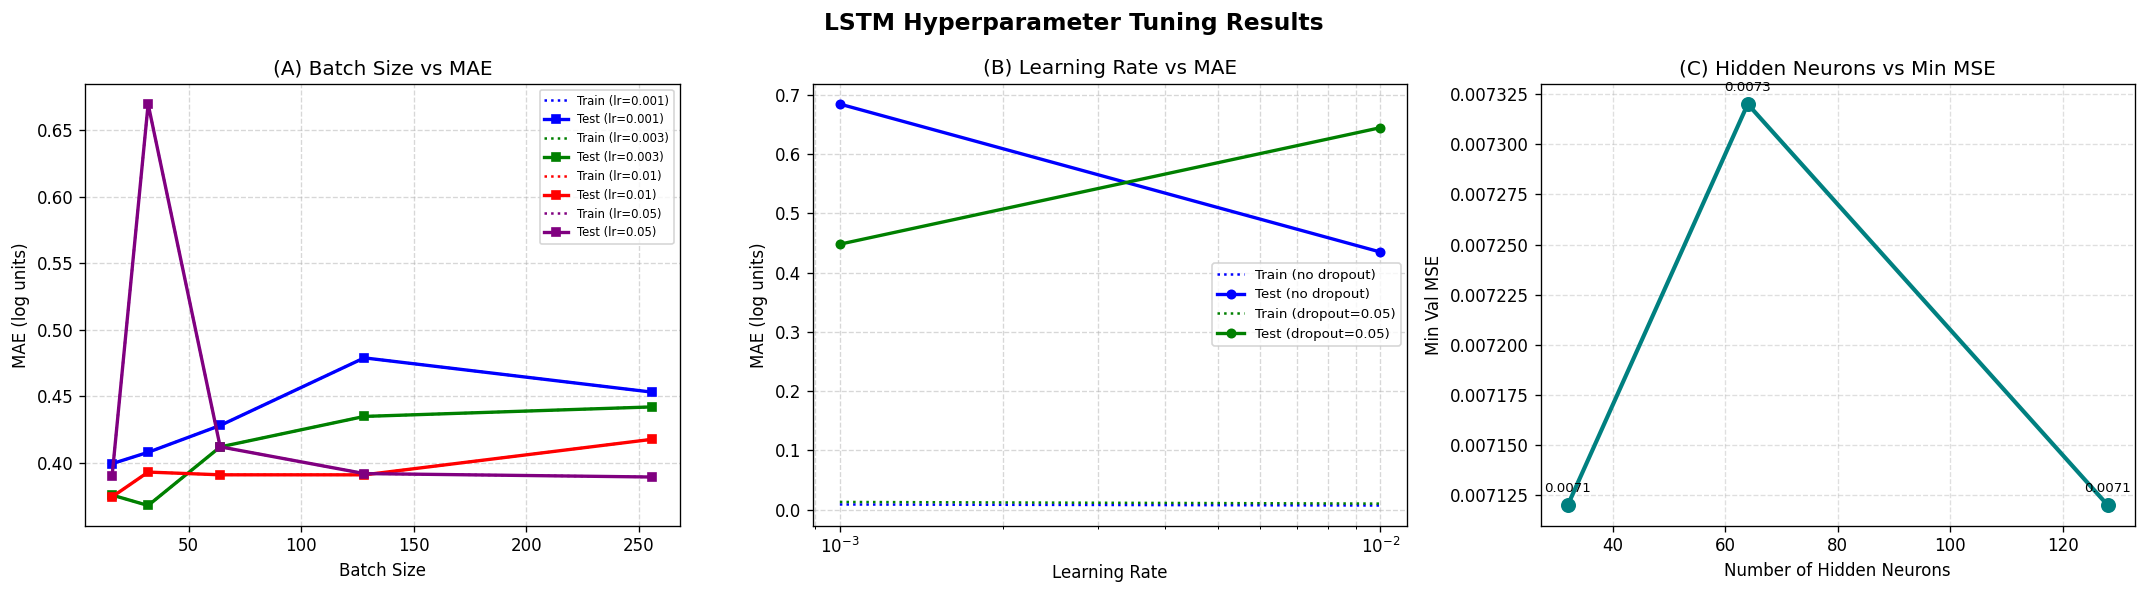

Saved: hyperparam_search.png


In [17]:
import matplotlib.pyplot as plt
COLORS=['blue','green','red','purple','orange']
fig,axes=plt.subplots(1,3,figsize=(18,5))
fig.suptitle("LSTM Hyperparameter Tuning Results",fontsize=14,fontweight='bold')

ax=axes[0]
for idx,lr in enumerate(learning_rates):
    sub=df_exp1[df_exp1.lr==lr].sort_values('bs'); col=COLORS[idx%len(COLORS)]
    ax.plot(sub.bs,sub.train_mae,ls=':',color=col,lw=1.5,label=f'Train (lr={lr})')
    ax.plot(sub.bs,sub.val_mae,ls='-',marker='s',ms=5,color=col,lw=2,label=f'Test (lr={lr})')
ax.set(title='(A) Batch Size vs MAE',xlabel='Batch Size',ylabel='MAE (log units)')
ax.legend(fontsize=7); ax.grid(True,ls='--',alpha=0.5)

ax=axes[1]
for idx,drop in enumerate(dropouts):
    sub=df_exp2[df_exp2.dropout==drop].sort_values('lr'); col=COLORS[idx%len(COLORS)]
    lbl='no dropout' if drop==0. else f'dropout={drop}'
    ax.plot(sub.lr,sub.train_mse,ls=':',color=col,lw=1.5,label=f'Train ({lbl})')
    ax.plot(sub.lr,sub.val_mae,  ls='-',marker='o',ms=5,color=col,lw=2,label=f'Test ({lbl})')
ax.set_xscale('log')
ax.set(title='(B) Learning Rate vs MAE',xlabel='Learning Rate',ylabel='MAE (log units)')
ax.legend(fontsize=8); ax.grid(True,ls='--',alpha=0.5,which='both')

ax=axes[2]
ax.plot(res_exp3['neurons'],res_exp3['min_mse'],marker='o',color='teal',lw=2.5,ms=8)
ax.set(title='(C) Hidden Neurons vs Min MSE',
       xlabel='Number of Hidden Neurons',ylabel='Min Val MSE')
for n,m in zip(res_exp3['neurons'],res_exp3['min_mse']):
    ax.annotate(f'{m:.4f}',(n,m),xytext=(0,8),textcoords='offset points',ha='center',fontsize=8)

plt.tight_layout()
plt.savefig('hyperparam_search.png',dpi=150,bbox_inches='tight')
plt.show(); print("Saved: hyperparam_search.png")

## 10. Final Model Training  *(Full Dataset, Best Params)*

In [ ]:
def train_lstm(Xtr, ytr, Xvl, yvl,
               hidden=64, lr=1e-3, bs=256, epochs=60,
               patience=10, dropout=0.2, verbose=True, tag=""):
    pin=(device.type=="cuda")
    loader=DataLoader(TensorDataset(torch.FloatTensor(Xtr),torch.FloatTensor(ytr)),
                      batch_size=bs, shuffle=True, pin_memory=pin, num_workers=0)  # ← fixed
    n_sa=ytr.shape[1]-2
    model=LSTMGroundMotion(Xtr.shape[1],hidden,n_sa,dropout).to(device)
    crit=nn.MSELoss()
    opt=optim.AdamW(model.parameters(),lr=lr,weight_decay=1e-4)
    sched=optim.lr_scheduler.CosineAnnealingLR(opt,T_max=epochs,eta_min=lr/20)
    gs=GradScaler("cuda",enabled=USE_AMP)
    Xvl_t=torch.FloatTensor(Xvl).to(device); yvl_t=torch.FloatTensor(yvl).to(device)

    best_val,best_state,pctr,best_ep=float('inf'),None,0,0
    th,vh=[],[]
    hdr=f"{'Epoch':>6} {'TrainMSE':>10} {'ValMSE':>10} {'ValMAE':>10} {'ValR2':>8} {'LR':>10}"
    if verbose: print(f"\n{tag}"); print(hdr); print("-"*len(hdr))

    for ep in range(epochs):
        model.train(); tloss=0.
        for bX,by in loader:
            bX=bX.to(device,non_blocking=True); by=by.to(device,non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with autocast("cuda",enabled=USE_AMP):
                loss=crit(model(bX,y_sa=by[:,2:]),by)
            gs.scale(loss).backward()
            gs.unscale_(opt); nn.utils.clip_grad_norm_(model.parameters(),1.0)
            gs.step(opt); gs.update()
            tloss+=loss.item()
        tloss/=len(loader); th.append(tloss); sched.step()

        model.eval()
        with torch.no_grad(), autocast("cuda",enabled=USE_AMP):
            vout=model(Xvl_t,y_sa=yvl_t[:,2:])
            vloss=crit(vout,yvl_t).item()
        vh.append(vloss)
        vo=vout.cpu().numpy()
        vmae=mean_absolute_error(yvl,vo); vr2=r2_score(yvl,vo)
        cur_lr=sched.get_last_lr()[0]
        if verbose:
            print(f"{ep+1:>6}   {tloss:>10.6f}   {vloss:>10.6f}   {vmae:>10.6f}   {vr2:>8.4f}   {cur_lr:>10.2e}")

        if vloss<best_val:
            best_val,best_ep,pctr=vloss,ep,0
            best_state=copy.deepcopy(model.state_dict())
        else:
            pctr+=1
        if pctr>=patience:
            if verbose: print(f"  Early stop @ ep {ep+1}  best@{best_ep+1}"); break

    model.load_state_dict(best_state)
    return dict(model=model,th=th,vh=vh,best_ep=best_ep,best_val=best_val,train_loss=th[best_ep])

def fast_pred(model, Xs):
    model.eval()
    with torch.no_grad():
        return sy.inverse_transform(model(torch.FloatTensor(Xs).to(device)).cpu().numpy())

print("train_lstm() ready -- prints Epoch | TrainMSE | ValMSE | ValMAE | ValR2 | LR")

train_lstm() ready -- prints Epoch | TrainMSE | ValMSE | ValMAE | ValR2 | LR


In [18]:
print("="*70)
best_bs=16; best_lr=0.01; best_drop=0.0; best_hs=128
print("BEST PARAMETERS FOUND DURING TUNING:")
print(f"  Learning Rate : {best_lr}")
print(f"  Batch Size    : {best_bs}")
print(f"  Dropout Rate  : {best_drop}")
print(f"  Neurons       : {best_hs}")
print("="*70+"\nTraining final model for up to 150 epochs ...\n")

final_result=train_lstm(X_train_s,y_train_s,X_val_s,y_val_s,
    hidden=best_hs,lr=best_lr,bs=best_bs,epochs=5,patience=20,
    dropout=best_drop,verbose=True,tag="FINAL MODEL")
best_model=final_result['model']

with torch.no_grad():
    y_pred_test_s=best_model(torch.FloatTensor(X_test_s).to(device)).cpu().numpy()
y_pred_test=sy.inverse_transform(y_pred_test_s)

test_mse=mean_squared_error(y_test,y_pred_test)
test_mae=mean_absolute_error(y_test,y_pred_test)
test_r2 =r2_score(y_test,y_pred_test)
print("\n"+"="*50)
print("FINAL MODEL METRICS (TEST SET):")
print(f"  Test MSE : {test_mse:.6f}")
print(f"  Test MAE : {test_mae:.6f}")
print(f"  Test R2  : {test_r2:.6f}")
print("="*50)

BEST PARAMETERS FOUND DURING TUNING:
  Learning Rate : 0.01
  Batch Size    : 16
  Dropout Rate  : 0.0
  Neurons       : 128
Training final model for up to 150 epochs ...


FINAL MODEL
 Epoch   TrainMSE     ValMSE     ValMAE    ValR2         LR
-----------------------------------------------------------
     1     0.025418     0.010408     0.058311     0.9895     9.09e-03
     2     0.009126     0.015318     0.072949     0.9846     6.72e-03
     3     0.008102     0.007520     0.037450     0.9924     3.78e-03
     4     0.007044     0.007107     0.039299     0.9928     1.41e-03
     5     0.006663     0.006658     0.035876     0.9933     5.00e-04

FINAL MODEL METRICS (TEST SET):
  Test MSE : 0.218616
  Test MAE : 0.359554
  Test R2  : 0.777388


## 11. MSE Loss vs Epochs

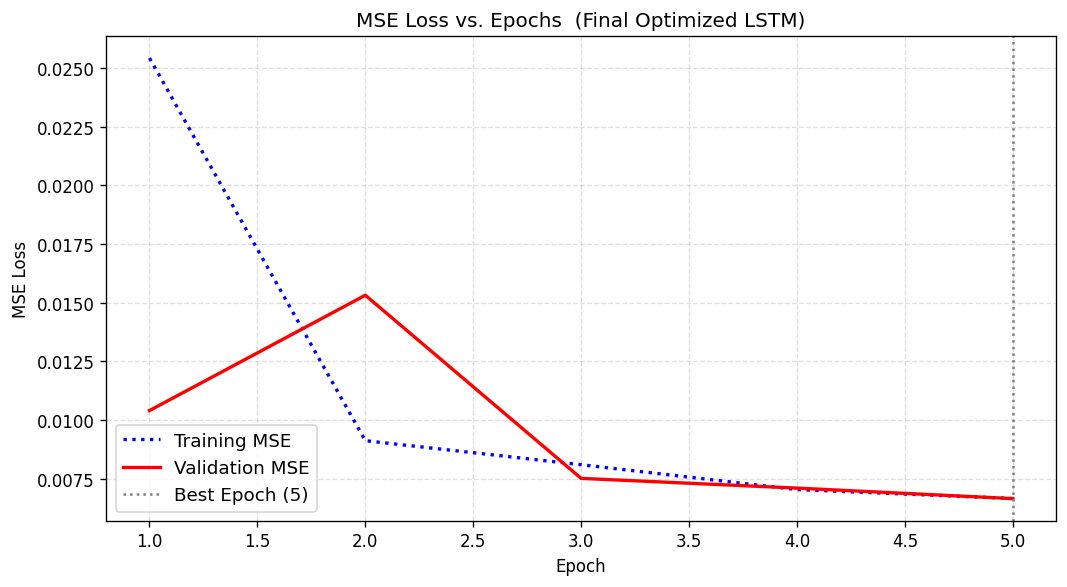

Saved: loss_curves.png


In [19]:
fig,ax=plt.subplots(figsize=(9,5))
ep=range(1,len(final_result['th'])+1)
ax.plot(ep,final_result['th'],'b:',lw=2, label='Training MSE')
ax.plot(ep,final_result['vh'],'r-',lw=2, label='Validation MSE')
ax.axvline(final_result['best_ep']+1,color='gray',ls=':',lw=1.5,
           label=f"Best Epoch ({final_result['best_ep']+1})")
ax.set(xlabel='Epoch',ylabel='MSE Loss',
       title='MSE Loss vs. Epochs  (Final Optimized LSTM)')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('loss_curves.png',dpi=150,bbox_inches='tight')
plt.show(); print("Saved: loss_curves.png")

## 12. Observed vs Predicted  *(PGA, PGV, Sa@0.2s, Sa@1s)*

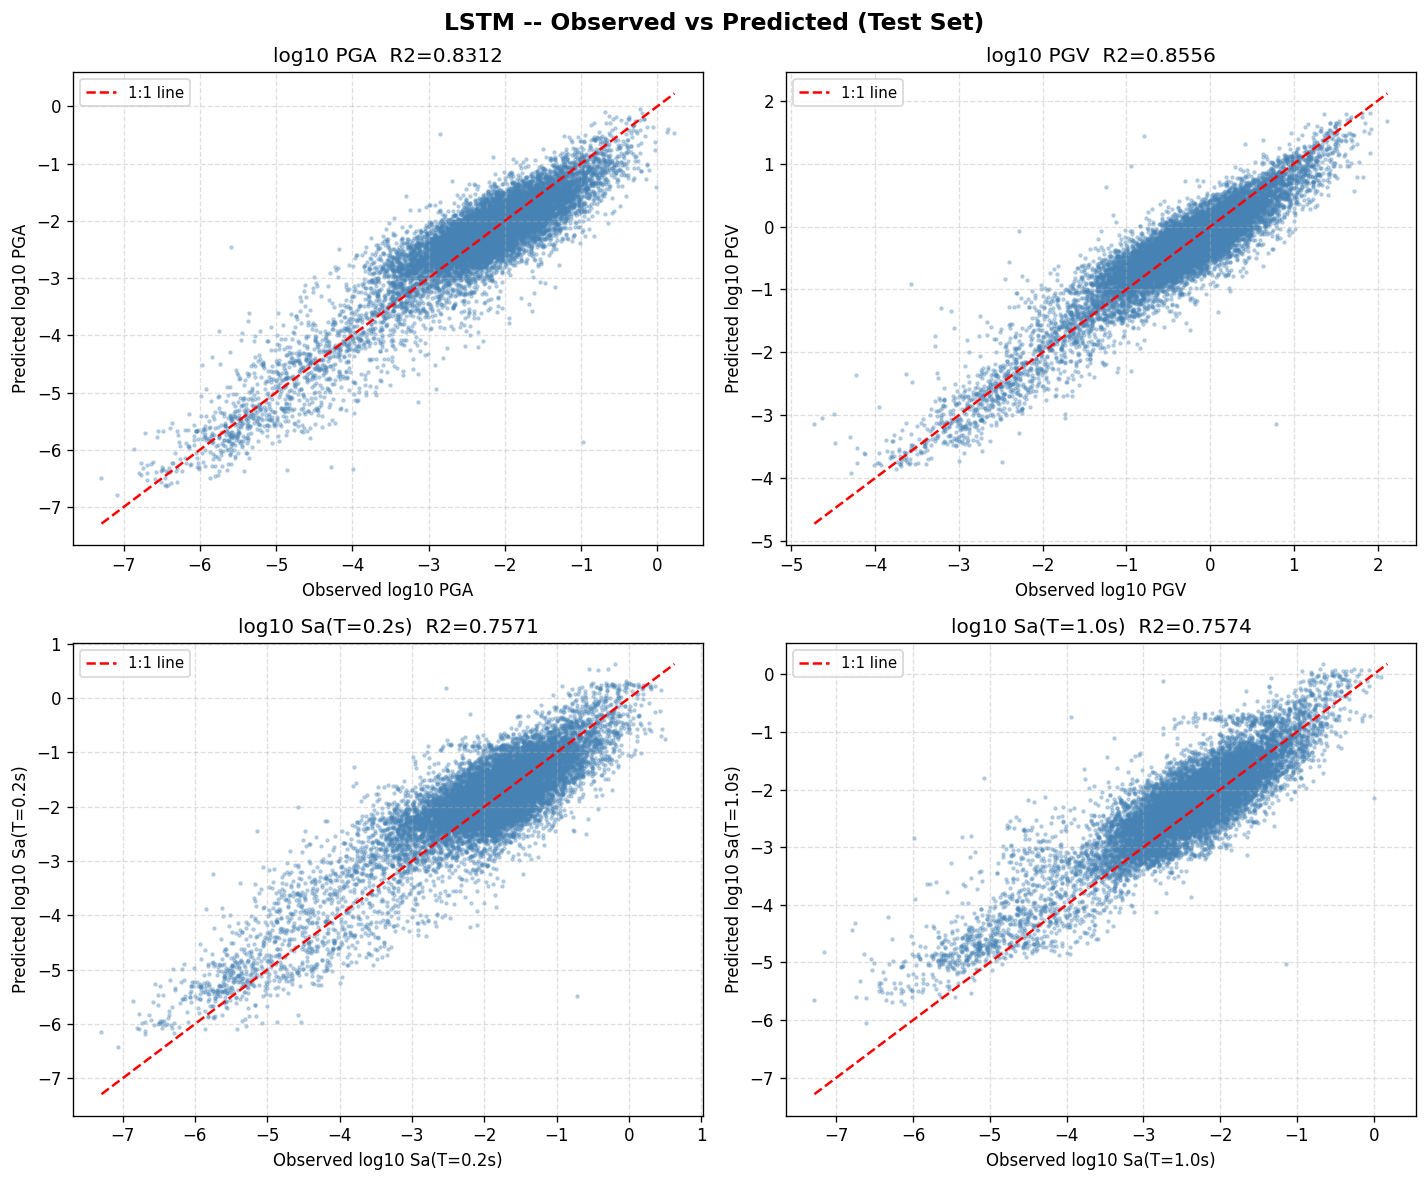

Saved: obs_vs_pred.png


In [20]:
idx_map={'log10 PGA':0,'log10 PGV':1,
           'log10 Sa(T=0.2s)': 2+int(np.searchsorted(periods_arr,0.2)),
           'log10 Sa(T=1.0s)': 2+int(np.searchsorted(periods_arr,1.0))}
fig,axes=plt.subplots(2,2,figsize=(12,10))
fig.suptitle('LSTM -- Observed vs Predicted (Test Set)',fontsize=14,fontweight='bold')
for ax,(label,ti) in zip(axes.flatten(),idx_map.items()):
    obs=y_test[:,ti]; pred=y_pred_test[:,ti]
    r2=r2_score(obs,pred); mn,mx=min(obs.min(),pred.min()),max(obs.max(),pred.max())
    ax.scatter(obs,pred,s=3,alpha=0.3,color='steelblue',rasterized=True)
    ax.plot([mn,mx],[mn,mx],'r--',lw=1.5,label='1:1 line')
    ax.set(xlabel=f'Observed {label}',ylabel=f'Predicted {label}',
           title=f'{label}  R2={r2:.4f}')
    ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('obs_vs_pred.png',dpi=150,bbox_inches='tight')
plt.show(); print("Saved: obs_vs_pred.png")

## 13. Residual Analysis  *(3×2 grid: Whole Dataset & Test Set)*

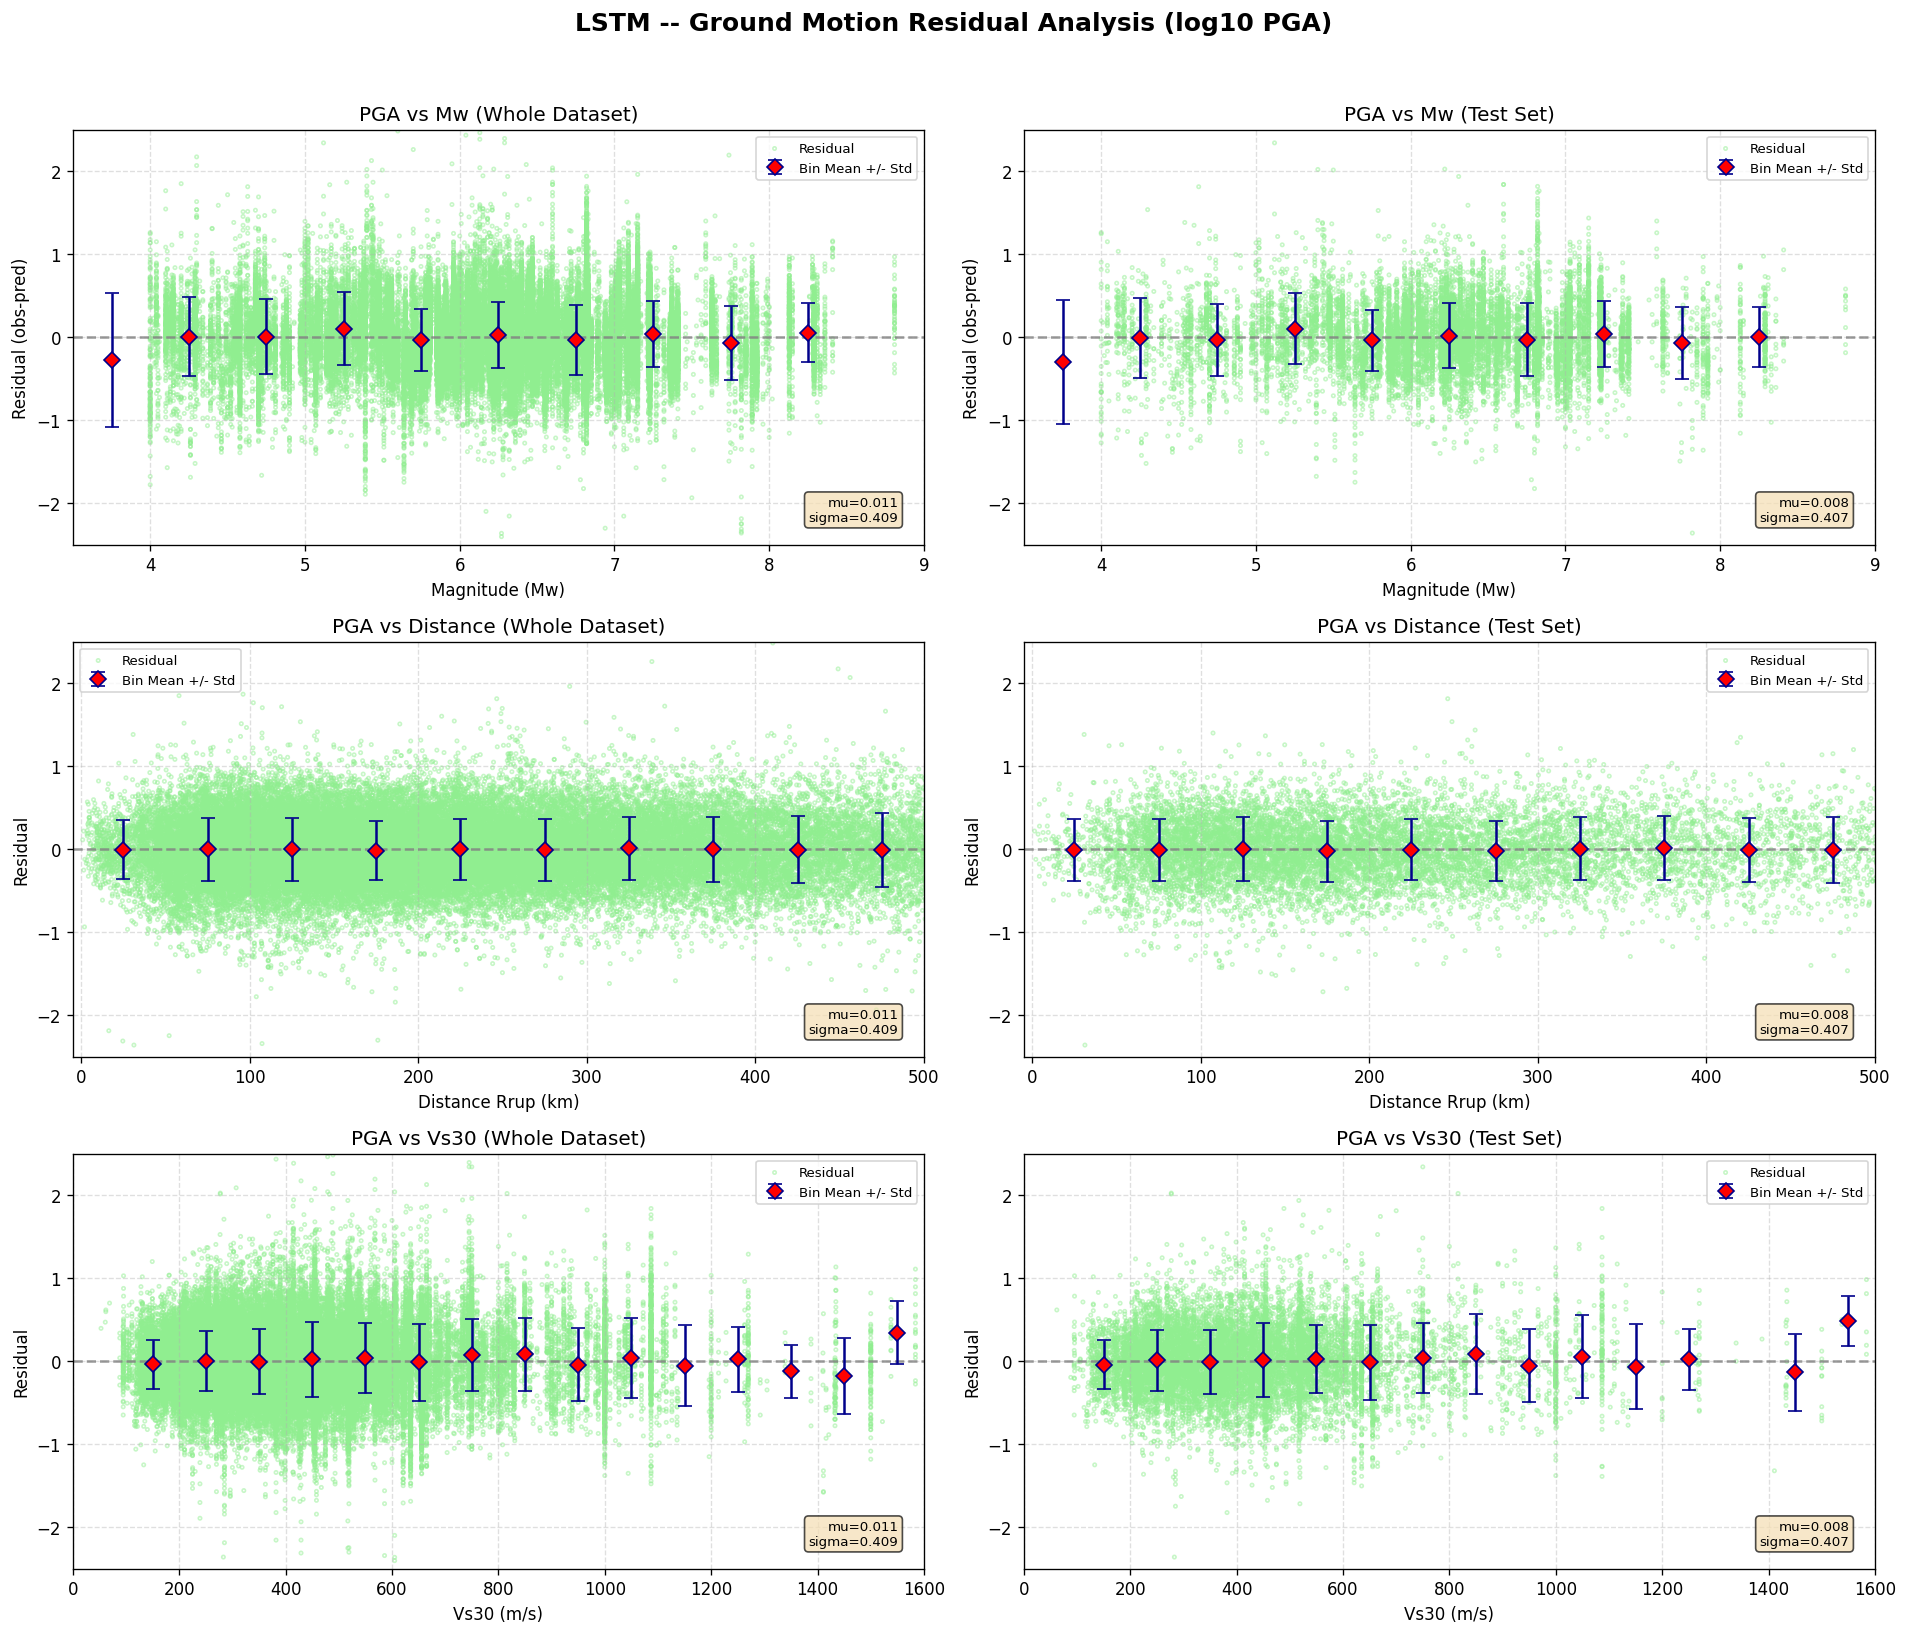

Saved: residual_analysis.png


In [21]:
X_all_s=sX.transform(X_all)
best_model.eval()
with torch.no_grad():
    y_pred_all=sy.inverse_transform(
        best_model(torch.FloatTensor(X_all_s).to(device)).cpu().numpy())

resid_all =y_all[:,0]-y_pred_all[:,0]
resid_test=y_test[:,0]-y_pred_test[:,0]
Mw_all=X_all[:,0];    Mw_tst=X_test[:,0]
Rrp_all=X_all[:,1];   Rrp_tst=X_test[:,1]
Vs30_all=10**X_all[:,3]; Vs30_tst=10**X_test[:,3]

def plot_panel(ax,x,resid,bins,xlabel,ylabel,title,xlim):
    ax.scatter(x,resid,facecolors='none',edgecolors='lightgreen',
               s=4,alpha=0.5,rasterized=True,label='Residual')
    cents=bins[:-1]+np.diff(bins)/2; bm,bs_=[],[]
    for lo,hi in zip(bins[:-1],bins[1:]):
        m=(x>=lo)&(x<=hi)
        if m.sum()>5: bm.append(np.mean(resid[m])); bs_.append(np.std(resid[m]))
        else:         bm.append(np.nan); bs_.append(np.nan)
    ax.errorbar(cents,bm,yerr=bs_,fmt='D',markerfacecolor='red',
                markeredgecolor='darkblue',ecolor='darkblue',
                ms=7,capsize=4,label='Bin Mean +/- Std',zorder=5)
    ax.axhline(0,color='gray',ls='--',alpha=0.8)
    ax.set(title=title,xlabel=xlabel,ylabel=ylabel,xlim=xlim,ylim=(-2.5,2.5))
    ax.legend(fontsize=8)
    ax.text(0.97,0.05,f'mu={np.nanmean(resid):.3f}\nsigma={np.nanstd(resid):.3f}',
            transform=ax.transAxes,ha='right',va='bottom',fontsize=8,
            bbox=dict(boxstyle='round',fc='wheat',alpha=0.7))

bins_mag =np.arange(3.0,9.0,0.5)
bins_dist=np.arange(0,550,50)
bins_vs  =np.arange(100,1700,100)
fig,axes=plt.subplots(3,2,figsize=(16,14))
fig.suptitle('LSTM -- Ground Motion Residual Analysis (log10 PGA)',
             fontsize=15,fontweight='bold',y=0.99)

plot_panel(axes[0,0],Mw_all,resid_all,bins_mag,'Magnitude (Mw)',
           'Residual (obs-pred)','PGA vs Mw (Whole Dataset)',(3.5,9))
plot_panel(axes[0,1],Mw_tst,resid_test,bins_mag,'Magnitude (Mw)',
           'Residual (obs-pred)','PGA vs Mw (Test Set)',(3.5,9))
plot_panel(axes[1,0],Rrp_all,resid_all,bins_dist,'Distance Rrup (km)',
           'Residual','PGA vs Distance (Whole Dataset)',(-5,500))
plot_panel(axes[1,1],Rrp_tst,resid_test,bins_dist,'Distance Rrup (km)',
           'Residual','PGA vs Distance (Test Set)',(-5,500))
plot_panel(axes[2,0],Vs30_all,resid_all,bins_vs,'Vs30 (m/s)',
           'Residual','PGA vs Vs30 (Whole Dataset)',(0,1600))
plot_panel(axes[2,1],Vs30_tst,resid_test,bins_vs,'Vs30 (m/s)',
           'Residual','PGA vs Vs30 (Test Set)',(0,1600))

plt.tight_layout(rect=[0,0.02,1,0.97])
plt.savefig('residual_analysis.png',dpi=150,bbox_inches='tight')
plt.show(); print("Saved: residual_analysis.png")

## 14. Feature Importance  *(Permutation — Global)*

Permutation: 100%|██████████| 5/5 [02:34<00:00, 30.82s/it]


Feature Importance:
  Earthquake_Magnitude          44.03%
  log10_Rrp                     27.68%
  ClstD_km                      21.94%
  Fault_Type                    3.19%
  log10_Vs30                    3.16%


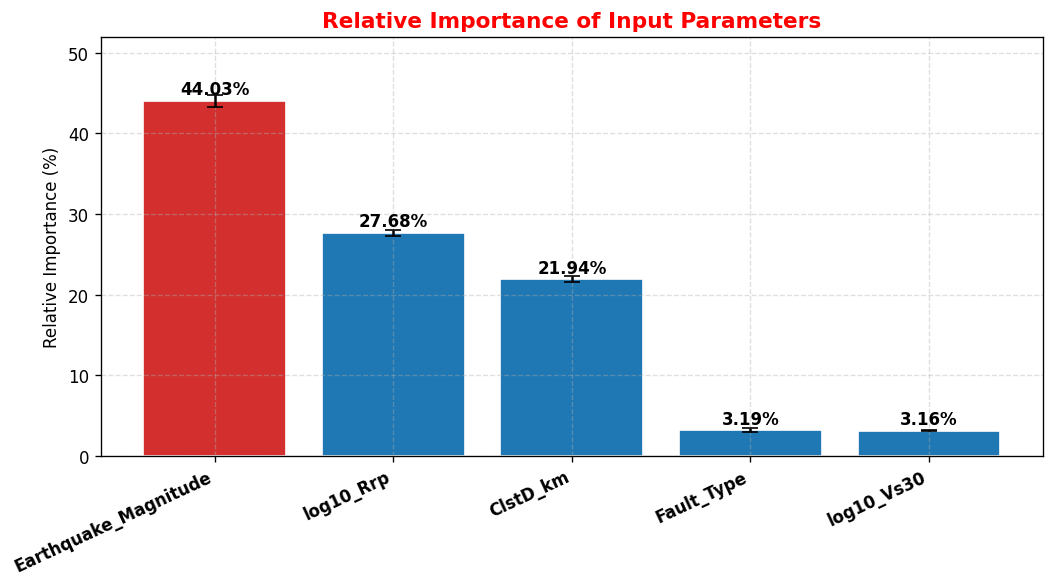

Saved: feature_importance.png


In [22]:
feat_labels=INPUT_COLS[:]
baseline_mse=mean_squared_error(y_test,y_pred_test)
N_REP=5
imps=np.zeros((N_REP,len(feat_labels)))
for rep in tqdm(range(N_REP),desc="Permutation"):
    for fi in range(len(feat_labels)):
        Xp=X_test_s.copy(); np.random.shuffle(Xp[:,fi])
        pp=sy.inverse_transform(best_model(torch.FloatTensor(Xp).to(device)).detach().cpu().numpy())
        imps[rep,fi]=(mean_squared_error(y_test,pp)-baseline_mse)/baseline_mse*100

imp_mean=imps.mean(0); imp_std=imps.std(0)
imp_pct=imp_mean/imp_mean.sum()*100
order=np.argsort(imp_pct)[::-1]
print("Feature Importance:")
for i in order: print(f"  {feat_labels[i]:28s}  {imp_pct[i]:.2f}%")

fig,ax=plt.subplots(figsize=(9,5))
colors_bar=['#D32F2F' if imp_pct[i]==imp_pct.max() else '#1f77b4' for i in order]
bars=ax.bar([feat_labels[i] for i in order],[imp_pct[i] for i in order],
            yerr=[imp_std[i]/imp_mean.sum()*100 for i in order],
            color=colors_bar,edgecolor='white',capsize=5)
for bar,v in zip(bars,[imp_pct[i] for i in order]):
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.3,
            f'{v:.2f}%',ha='center',va='bottom',fontweight='bold',fontsize=10)
ax.set(ylabel='Relative Importance (%)',title='Relative Importance of Input Parameters')
ax.set_title(ax.get_title(),color='red',fontweight='bold',fontsize=13)
plt.xticks(rotation=25,ha='right',fontweight='bold')
plt.ylim(0,max([imp_pct[i] for i in order])*1.18)
plt.tight_layout()
plt.savefig('feature_importance.png',dpi=150,bbox_inches='tight')
plt.show(); print("Saved: feature_importance.png")

## 15. SHAP Beeswarm Analysis  *(2×2 grid)*

100%|██████████| 100/100 [01:35<00:00,  1.05it/s]


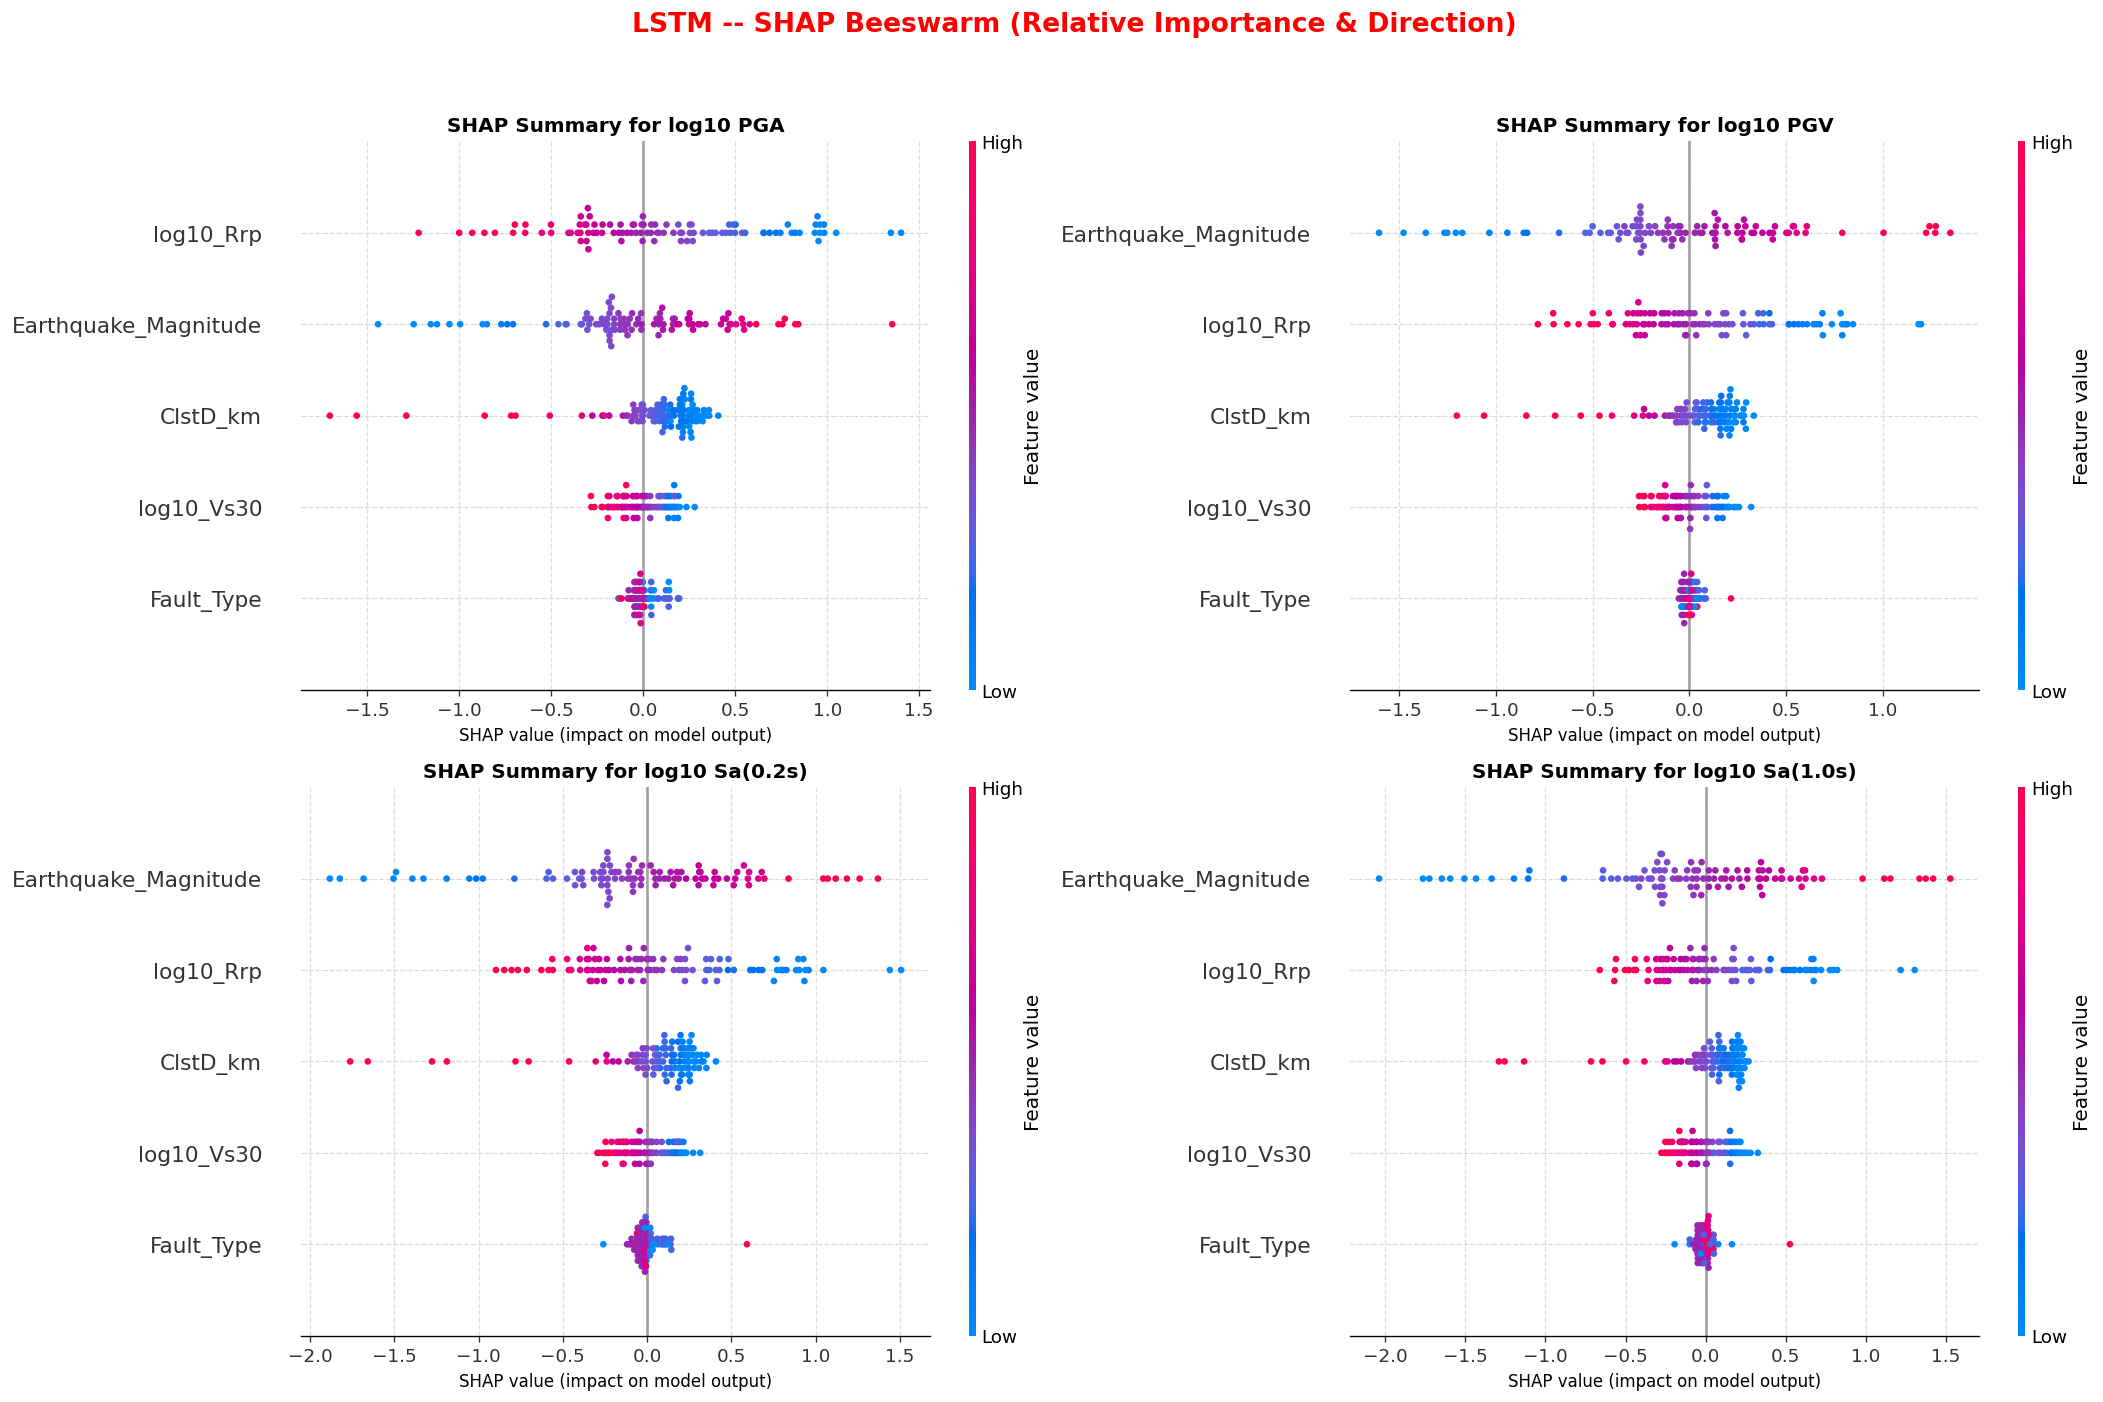

Saved: shap_beeswarm.png


In [23]:
try:
    import shap; HAS_SHAP=True
except ImportError:
    print("pip install shap"); HAS_SHAP=False

if HAS_SHAP:
    sa_02=2+int(np.searchsorted(periods_arr,0.2))
    sa_10=2+int(np.searchsorted(periods_arr,1.0))
    target_map={0:'log10 PGA',1:'log10 PGV',sa_02:'log10 Sa(0.2s)',sa_10:'log10 Sa(1.0s)'}
    background =shap.sample(X_train_s,100,random_state=42)
    shap_samp  =shap.sample(X_test_s, 100,random_state=42)
    feat_disp  =pd.DataFrame(sX.inverse_transform(shap_samp),columns=INPUT_COLS)

    def make_fn(tidx):
        def fn(Xn):
            best_model.eval()
            with torch.no_grad():
                return sy.inverse_transform(best_model(torch.FloatTensor(Xn).to(device)).cpu().numpy())[:,tidx]
        return fn

    fig=plt.figure(figsize=(18,12))
    plt.suptitle('LSTM -- SHAP Beeswarm (Relative Importance & Direction)',
                 fontsize=16,fontweight='bold',color='red',y=0.99)
    for i,(tidx,tname) in enumerate(target_map.items()):
        plt.subplot(2,2,i+1)
        exp=shap.KernelExplainer(make_fn(tidx),background)
        sv=exp.shap_values(shap_samp,nsamples=100)
        shap.summary_plot(sv,feat_disp,show=False,plot_size=None,max_display=5)
        plt.title(f'SHAP Summary for {tname}',fontsize=12,fontweight='bold')
        plt.xlabel('SHAP value (impact on model output)',fontsize=10)
    plt.tight_layout(rect=[0,0.02,1,0.96])
    plt.savefig('shap_beeswarm.png',dpi=150,bbox_inches='tight')
    plt.show(); print("Saved: shap_beeswarm.png")

## 16. Parametric Study — Response Spectra  *(3 Plots)*

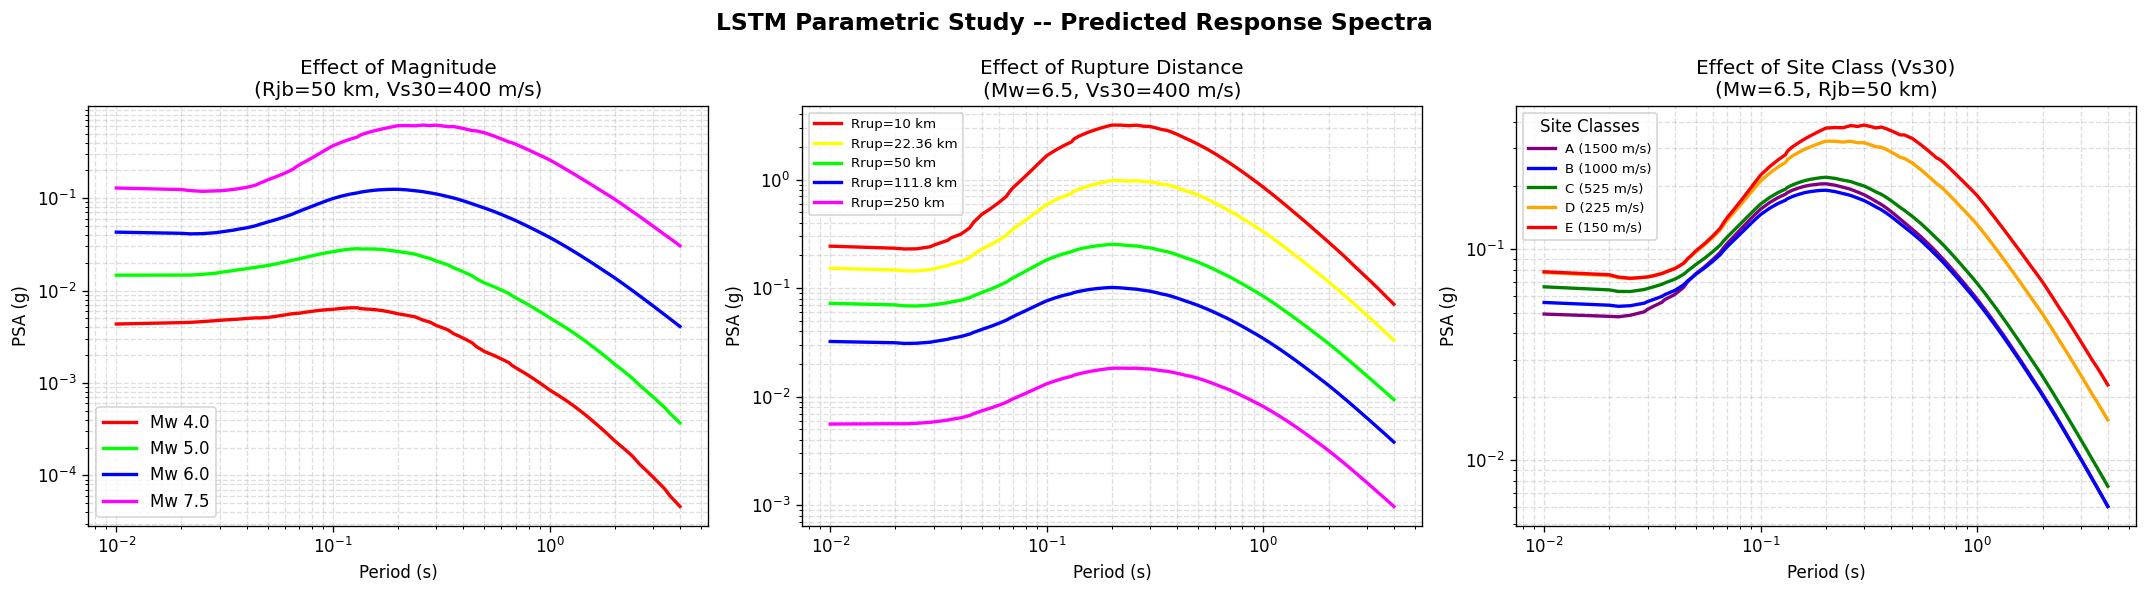

Saved: parametric_study.png


In [24]:
def predict_spec(Mw,Rjb,Vs30,fault=0):
    xr=np.array([[Mw,Rjb,np.log10(Rjb),np.log10(Vs30),fault]],dtype=np.float32)
    xs=sX.transform(xr)
    best_model.eval()
    with torch.no_grad():
        out_s=best_model(torch.FloatTensor(xs).to(device)).cpu().numpy()
    return 10**sy.inverse_transform(out_s)[0,2:]

fig,axes=plt.subplots(1,3,figsize=(18,5))
fig.suptitle("LSTM Parametric Study -- Predicted Response Spectra",fontsize=14,fontweight='bold')

# (1) Magnitude
ax=axes[0]
for mw,col in zip([4.0,5.0,6.0,7.5],['red','lime','blue','magenta']):
    ax.plot(periods_arr,predict_spec(mw,50,400),lw=2,color=col,label=f'Mw {mw}')
ax.set(xscale='log',yscale='log',xlabel='Period (s)',ylabel='PSA (g)',
       title='Effect of Magnitude\n(Rjb=50 km, Vs30=400 m/s)')
ax.legend(); ax.grid(True,which='both',alpha=0.4)

# (2) Distance
ax=axes[1]
for rjb,col in zip([10,22.36,50,111.8,250],['red','yellow','lime','blue','magenta']):
    ax.plot(periods_arr,predict_spec(6.5,rjb,400),lw=2,color=col,label=f'Rrup={rjb} km')
ax.set(xscale='log',yscale='log',xlabel='Period (s)',ylabel='PSA (g)',
       title='Effect of Rupture Distance\n(Mw=6.5, Vs30=400 m/s)')
ax.legend(fontsize=8); ax.grid(True,which='both',alpha=0.4)

# (3) Vs30 / Site Class
ax=axes[2]
for lbl,vs30,col in [('A',1500,'purple'),('B',1000,'blue'),('C',525,'green'),
                      ('D',225,'orange'),('E',150,'red')]:
    ax.plot(periods_arr,predict_spec(6.5,50,vs30),lw=2,color=col,label=f'{lbl} ({vs30} m/s)')
ax.set(xscale='log',yscale='log',xlabel='Period (s)',ylabel='PSA (g)',
       title='Effect of Site Class (Vs30)\n(Mw=6.5, Rjb=50 km)')
ax.legend(fontsize=8,title='Site Classes'); ax.grid(True,which='both',alpha=0.4)

plt.tight_layout()
plt.savefig('parametric_study.png',dpi=150,bbox_inches='tight')
plt.show(); print("Saved: parametric_study.png")

## 17. Summary

In [25]:
print("="*60)
print("LSTM GROUND MOTION MODEL -- FINAL SUMMARY")
print("="*60)
print(f"  Learning Rate  : {best_lr}")
print(f"  Batch Size     : {best_bs}")
print(f"  Dropout Rate   : {best_drop}")
print(f"  Hidden Neurons : {best_hs}")
print(f"  Best Val MSE   : {final_result['best_val']:.6f}")
print(f"  Test MSE       : {test_mse:.6f}")
print(f"  Test MAE       : {test_mae:.6f}")
print(f"  Test R2        : {test_r2:.6f}")
print("="*60)
print("\nGenerated Plots:")
for fn in ['hyperparam_search.png','loss_curves.png','obs_vs_pred.png',
           'residual_analysis.png','feature_importance.png',
           'shap_beeswarm.png','parametric_study.png']:
    ok="OK" if os.path.exists(fn) else "MISSING"
    print(f"  [{ok}]  {fn}")

LSTM GROUND MOTION MODEL -- FINAL SUMMARY
  Learning Rate  : 0.01
  Batch Size     : 16
  Dropout Rate   : 0.0
  Hidden Neurons : 128
  Best Val MSE   : 0.006658
  Test MSE       : 0.218616
  Test MAE       : 0.359554
  Test R2        : 0.777388

Generated Plots:
  [OK]  hyperparam_search.png
  [OK]  loss_curves.png
  [OK]  obs_vs_pred.png
  [OK]  residual_analysis.png
  [OK]  feature_importance.png
  [OK]  shap_beeswarm.png
  [OK]  parametric_study.png
